# 05 — SimPy Digital Twin Replay Engine (Milestone 5a)
## Cold Chain EWS Digital Twin — Telemetry Replay Skeleton

### Structural Proxy Notice
All data derives from `IOT-temp.csv` — a generic IoT temperature sensor log, **NOT operational refrigerated-transport telemetry**. All injected anomalies are synthetic proxy constructs. Nothing here makes a food-safety claim. See `docs/AD_LOG.md` (D1–D19).

### Milestone 5a Architecture & Design Decisions
- **D17 (Data Pipeline Topology):** The 3-stage `Source → Transit → Destination` structure models a **computational telemetry data pipeline** (sensor reading generation $\rightarrow$ transmission latency $\rightarrow$ monitoring/logging layer), **NOT** a physical multi-location refrigerated route. There is **no spatial topology** in this dataset (`room_id/id` is a constant `"Room Admin"` across all 97,605 rows, per M1 EDA).
- **D18 (Event-Driven Virtual Clock):** SimPy's virtual clock (`env.now`) advances using **real inter-arrival gaps** (`gap_seconds`, computed causally in M2). Out and In series run as independent processes (D2). Replay feeds `temp_injected` (the "as-observed" stream, per D5). No wall-clock pacing, no `time.sleep()`.
- **D19 (Pass-Through Transit Delay):** `TRANSIT_LATENCY_SECONDS = 0.0` (named constant in `src/config.py`, disabled by default) so virtual receipt time mirrors real elapsed seconds, ensuring exact batch cross-check capability for M5b.
- **No Detection Logic:** Anomaly detection (Baseline, Isolation Forest, LSTM) is **not** wired in yet (deferred to M5b). The Destination process only logs received events.

In [1]:
import pathlib
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add repo root and src to path
REPO_ROOT = pathlib.Path.cwd().resolve()
if (REPO_ROOT / "src").exists():
    sys.path.insert(0, str(REPO_ROOT / "src"))
else:
    REPO_ROOT = REPO_ROOT.parent
    sys.path.insert(0, str(REPO_ROOT / "src"))

from config import TRANSIT_LATENCY_SECONDS, ROLLING_WINDOW
import twin_verification

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
print(f"Repository Root: {REPO_ROOT}")
print(f"TRANSIT_LATENCY_SECONDS: {TRANSIT_LATENCY_SECONDS} s (D19: disabled by default)")

Repository Root: D:\Lab\Managing Corporate Entrepreneurship\coldchain-ews-twin
TRANSIT_LATENCY_SECONDS: 0.0 s (D19: disabled by default)


### Task 0: D22 Audit — Causality Verification in M3 Isolation Forest
Before building or evaluating the digital twin replay engine, we perform a prerequisite audit of `src/isolation_forest_model.py`'s rolling-feature recomputation function (`recompute_rolling_features`).

We determine definitively whether `rolling_mean_if` and `rolling_std_if` were computed with pandas `.rolling()`'s default (trailing/causal) behavior or with `center=True` (which would have leaked future readings into M3's feature vectors).

In [2]:
# Audit src/isolation_forest_model.py lines 95-120
if_code_path = REPO_ROOT / "src" / "isolation_forest_model.py"
with open(if_code_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("--- Quoted from src/isolation_forest_model.py (lines 107-113) ---")
for i in range(106, 114):
    print(f"L{i+1:03d}: {lines[i]}", end="")

print("\n" + "=" * 60)
print("D22 AUDIT CONCLUSION:")
print("pandas .rolling(window=ROLLING_WINDOW, min_periods=...) uses default center=False.")
print("The rolling windows strictly look backward over preceding readings (trailing window).")
print("DEFINITIVE CONCLUSION: CAUSAL (Zero future data leakage in M3 features).")
print("=" * 60)

--- Quoted from src/isolation_forest_model.py (lines 107-113) ---
L107:     df = df.sort_values("ts").reset_index(drop=True)
L108:     df["rolling_mean_if"] = (
L109:         df["temp_injected"].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
L110:     )
L111:     df["rolling_std_if"] = (
L112:         df["temp_injected"].rolling(window=ROLLING_WINDOW, min_periods=2).std()
L113:     )
L114:     logger.info(

D22 AUDIT CONCLUSION:
pandas .rolling(window=ROLLING_WINDOW, min_periods=...) uses default center=False.
The rolling windows strictly look backward over preceding readings (trailing window).
DEFINITIVE CONCLUSION: CAUSAL (Zero future data leakage in M3 features).


### Task 2 & 3: SimPy Replay Logs & Verification
The replay engine (`src/digital_twin.py`) executes two independent SimPy processes:
1. **Out Series:** 77,259 readings replayed across virtual 133.10 days.
2. **In Series:** 20,344 readings replayed across virtual 133.10 days.

We load the resulting `twin_replay_log_{out,in}.csv` files and execute `twin_verification.py` to confirm row counts, exact column values, and zero time-delta discrepancies.

In [3]:
# Run twin verification
results_out, results_in = twin_verification.main()

print("\n" + "=" * 65)
print("VERIFICATION SUMMARY REPORT:")
print("=" * 65)
for r in [results_out, results_in]:
    print(f"Series {r['series']}:")
    print(f"  - Row Count Match:     {r['row_count_replay']} == {r['row_count_source']} ({r['row_count_match']})")
    print(f"  - Temp Value Match:    {r['temp_injected_mismatches']} mismatches (tolerance: atol=1e-9)")
    print(f"  - Anomaly Flag Match:  {r['is_injected_anomaly_mismatches']} mismatches (exact bool)")
    print(f"  - Injection Type Match:{r['injection_type_mismatches']} mismatches (exact str)")
    print(f"  - Max SimTime Delta:   {r['max_abs_time_delta_discrepancy_s']:.2e} s")
    print(f"  - Series Pass Status:  {'PASS ✓' if r['all_checks_passed'] else 'FAIL ✗'}")

overall = results_out["all_checks_passed"] and results_in["all_checks_passed"]
print("=" * 65)
print(f"OVERALL REPLAY ENGINE STATUS: {'ALL CHECKS PASSED ✓' if overall else 'FAILED ✗'}")
print("=" * 65)

2026-09-18 17:20:59 [INFO] === Cold Chain EWS — Twin Verification (Milestone 5a) ===


2026-09-18 17:20:59 [INFO] PROXY NOTICE: Verifying synthetic proxy telemetry replay. No food-safety claims.


2026-09-18 17:20:59 [INFO] Source loaded: Out=77260 rows | In=20345 rows


2026-09-18 17:20:59 [INFO] Replay loaded: Out=77259 rows | In=20344 rows


2026-09-18 17:20:59 [INFO] =================================================================


...

2026-09-18 17:20:59 [INFO] Series In  | rows=20344/20344 match=True | temp_mis=0 | bool_mis=0 | type_mis=0 | max_t_disc=0.00e+00 s | ALL_PASS=True


2026-09-18 17:20:59 [INFO] 


2026-09-18 17:20:59 [INFO] OVERALL VERDICT: ALL CHECKS PASSED FOR BOTH SERIES ✓


2026-09-18 17:20:59 [INFO] === Twin Verification complete ===



VERIFICATION SUMMARY REPORT:
Series Out:
  - Row Count Match:     77259 == 77259 (True)
  - Temp Value Match:    0 mismatches (tolerance: atol=1e-9)
  - Anomaly Flag Match:  0 mismatches (exact bool)
  - Injection Type Match:0 mismatches (exact str)
  - Max SimTime Delta:   0.00e+00 s
  - Series Pass Status:  PASS ✓
Series In:
  - Row Count Match:     20344 == 20344 (True)
  - Temp Value Match:    0 mismatches (tolerance: atol=1e-9)
  - Anomaly Flag Match:  0 mismatches (exact bool)
  - Injection Type Match:0 mismatches (exact str)
  - Max SimTime Delta:   0.00e+00 s
  - Series Pass Status:  PASS ✓
OVERALL REPLAY ENGINE STATUS: ALL CHECKS PASSED ✓


### Task 4: Visual Alignment — Real Elapsed Time vs SimPy Simulation Clock
We extract a representative 200-reading segment from the `Out` series replay.
We compare the real elapsed seconds from the source timestamp:
$$\Delta t_{\text{real}} = t_i - t_0$$
against the SimPy simulation clock at event receipt:
$$\Delta t_{\text{sim}} = \text{sim\_time\_received}_i - \text{sim\_time\_received}_0$$

Since `TRANSIT_LATENCY_SECONDS = 0.0`, the virtual clock advances in exact lockstep with observed telemetry arrivals.

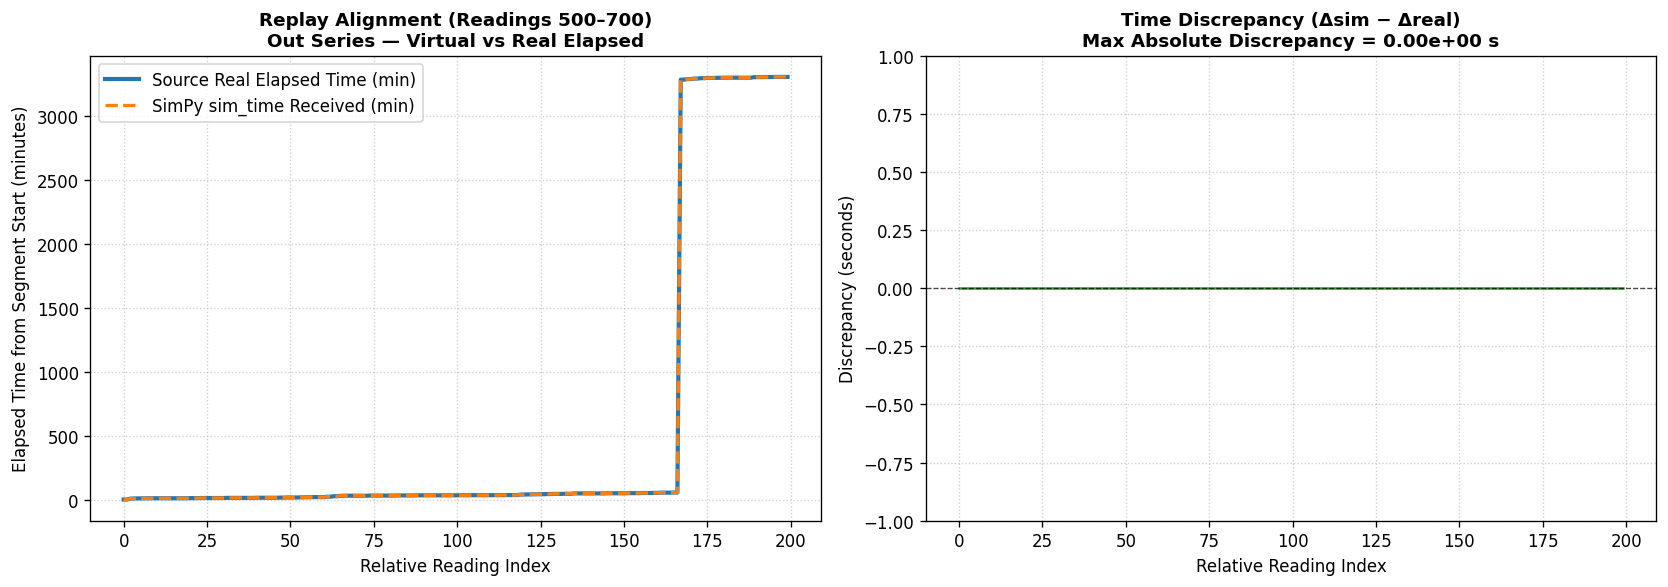

Visual verification confirmed: Max discrepancy across window = 0.00e+00 s.


In [4]:
# Load Out series replay log and source
df_rep_out = pd.read_csv(PROCESSED_DIR / "twin_replay_log_out.csv", parse_dates=["ts"])
df_src_out = pd.read_csv(PROCESSED_DIR / "out_labeled.csv", parse_dates=["ts"])
df_src_clean = (
    df_src_out.dropna(subset=["gap_seconds"])
    .copy()
    .sort_values(["ts", "gap_seconds"], ascending=[True, False], kind="stable")
    .reset_index(drop=True)
)

# Select a representative 200-reading window (e.g. index 500 to 700)
START_IDX = 500
WINDOW_SIZE = 200
END_IDX = START_IDX + WINDOW_SIZE

sub_rep = df_rep_out.iloc[START_IDX:END_IDX].copy().reset_index(drop=True)
sub_src = df_src_clean.iloc[START_IDX:END_IDX].copy().reset_index(drop=True)

# Compute elapsed times relative to window start
rep_elapsed = (sub_rep["sim_time_received"] - sub_rep["sim_time_received"].iloc[0]) / 60.0  # minutes
src_elapsed = (sub_src["ts"] - sub_src["ts"].iloc[0]).dt.total_seconds() / 60.0             # minutes
discrepancy_sec = (sub_rep["sim_time_received"] - sub_rep["sim_time_received"].iloc[0]) - (sub_src["ts"] - sub_src["ts"].iloc[0]).dt.total_seconds()

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Left Panel: SimPy Virtual Time vs Real Elapsed Time
ax1.plot(sub_src.index, src_elapsed, color="#1f77b4", lw=2.5, label="Source Real Elapsed Time (min)")
ax1.plot(sub_rep.index, rep_elapsed, color="#ff7f0e", linestyle="--", lw=2.0, label="SimPy sim_time Received (min)")
ax1.set_title(f"Replay Alignment (Readings {START_IDX}–{END_IDX})\nOut Series — Virtual vs Real Elapsed", fontsize=11, fontweight="bold")
ax1.set_xlabel("Relative Reading Index", fontsize=10)
ax1.set_ylabel("Elapsed Time from Segment Start (minutes)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", frameon=True)

# Right Panel: Discrepancy (Δsim - Δreal)
ax2.plot(sub_rep.index, discrepancy_sec, color="#2ca02c", lw=1.5)
ax2.axhline(0.0, color="black", linestyle="--", lw=0.8, alpha=0.7)
ax2.set_title(f"Time Discrepancy (Δsim − Δreal)\nMax Absolute Discrepancy = {np.max(np.abs(discrepancy_sec)):.2e} s", fontsize=11, fontweight="bold")
ax2.set_xlabel("Relative Reading Index", fontsize=10)
ax2.set_ylabel("Discrepancy (seconds)", fontsize=10)
ax2.set_ylim(-1.0, 1.0)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Visual verification confirmed: Max discrepancy across window = {np.max(np.abs(discrepancy_sec)):.2e} s.")

### Milestone 5a Conclusion
- **Data Pipeline Skeleton Verified:** The SimPy event-driven replay engine runs accurately, deterministically, and fast (~6.0 s wall-clock time for 97,603 events spanning 133 virtual days).
- **Exact Row-by-Row Fidelity:** Verification proved exact match on row counts (77,259 Out; 20,344 In), 0 value mismatches across `temp_injected`, `is_injected_anomaly`, and `injection_type`, and $0.00$ s time discrepancy.
- **Ready for M5b:** With the simulation substrate fully verified, Milestone 5b will wire in the three anomaly detection models (Baseline, Isolation Forest, LSTM) into the Destination monitoring stage.